<a href="https://colab.research.google.com/github/mariaalejandragg31-tech/Codigo1/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

Usaremos como ejemplo:

**BLK**

**PFE**

**HON **

In [11]:
empresa=yf.Ticker("APPL")

In [6]:
import yfinance as yf
activos = ["BLK", "PFE", "HON"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos

[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker             BLK         HON        PFE         BLK         HON   
Date                                                                    
2024-01-02  753.558472  195.308731  24.844587  760.940602  196.813255   
2024-01-03  738.351746  191.131531  24.844587  746.129272  194.766704   
2024-01-04  740.046570  191.477310  24.309761  746.204580  192.710836   
2024-01-05  737.108826  190.197052  24.627314  742.692477  191.168914   
2024-01-08  750.630066  189.384018  24.719240  751.402181  190.215707   

Price                         Low                               Open  \
Ticker            PFE         BLK         HON        PFE         BLK   
Date                                                                   
2024-01-02  25.304209  748.972909  194.673272  24.092481  757.183647   
2024-01-03  25.103647  736.638036  190.879214  24.577172  746.129272   
2024-01-04  25.028441  737.014604  190.664302  24.259621  737.513677   
2024-01-05  24.644027  735.818845  189.010236  24.025629  737.089975   
2024-01-08  24.802808  737.184063  188.066377  24.376614  738.615305   

Price                              Volume                     
Ticker             HON        PFE     BLK      HON       PFE  
Date                                                          
2024-01-02  195.177892  24.134264  660000  3169238  57948700  
2024-01-03  194.766704  25.070220  638700  3858485  43426500  
2024-01-04  190.748403  24.894734  580200  2571649  45558200  
2024-01-05  191.000712  24.251261  471000  2713889  33612800  
2024-01-08  189.813884  24.535392  513200  4066887  32972100

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [25]:

cierre = precios["Close"]

cierre.head()

Ticker,BLK,HON,PFE
Date,,,
2024-01-02,753.558472,195.308731,24.844587
2024-01-03,738.351746,191.131531,24.844587
2024-01-04,740.046570,191.477310,24.309761
2024-01-05,737.108826,190.197052,24.627314
2024-01-08,750.630066,189.384018,24.719240


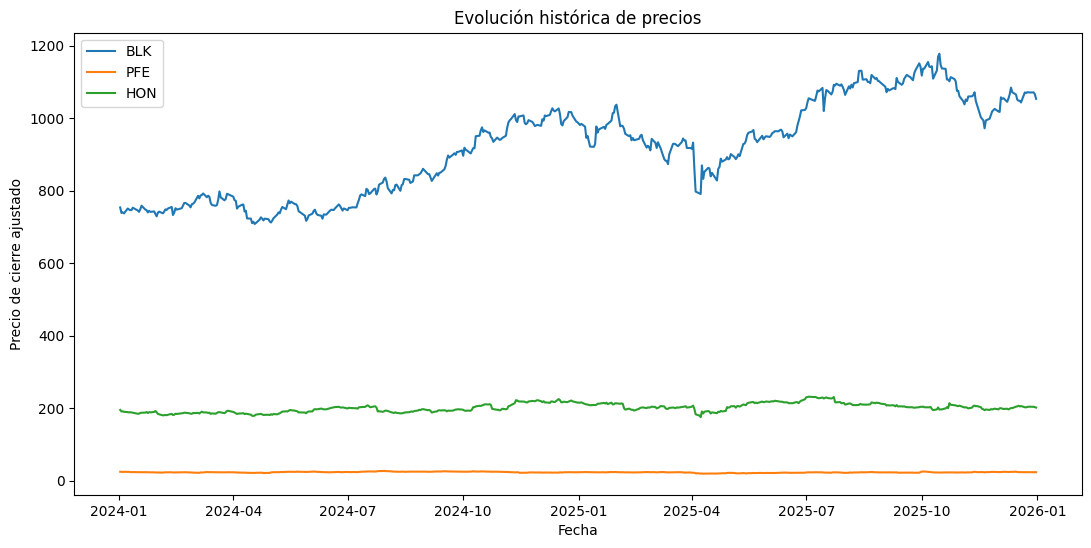

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))
for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre ajustado")
ax.legend()
plt.show()

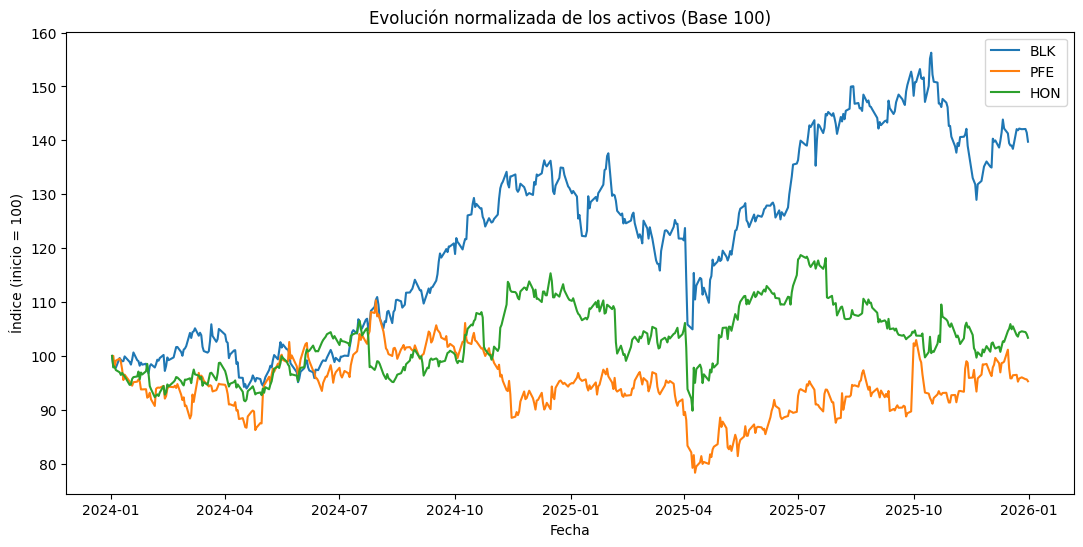

In [33]:
# 3. Normalizar y graficar en base 100
import matplotlib.pyplot as plt

# Calculamos la normalización base 100 (primer registro como base)
cierre_normalizado = (cierre / closure.iloc[0] if 'closure' in locals() else (cierre / cierre.iloc[0]) * 100)

fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos (Base 100)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

In [34]:
# 1. Calcular rendimientos


rendimientos = cierre.pct_change()

rendimientos.head()

Ticker,BLK,HON,PFE
Date,,,
2024-01-02,NaN,NaN,NaN
2024-01-03,-0.020180,-0.021388,0.000000
2024-01-04,0.002295,0.001809,-0.021527
2024-01-05,-0.003970,-0.006686,0.013063
2024-01-08,0.018344,-0.004275,0.003733


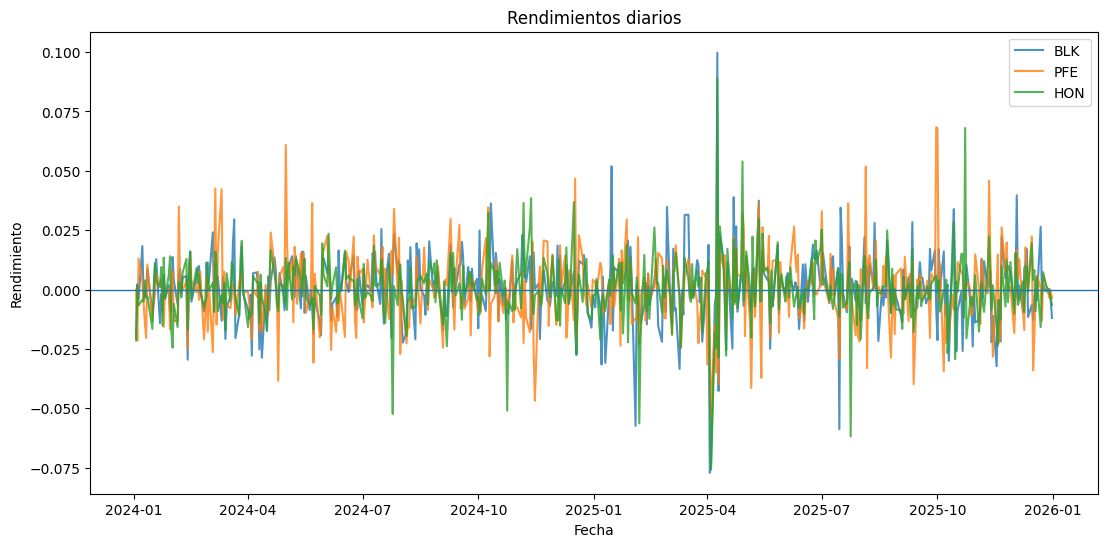

In [40]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()

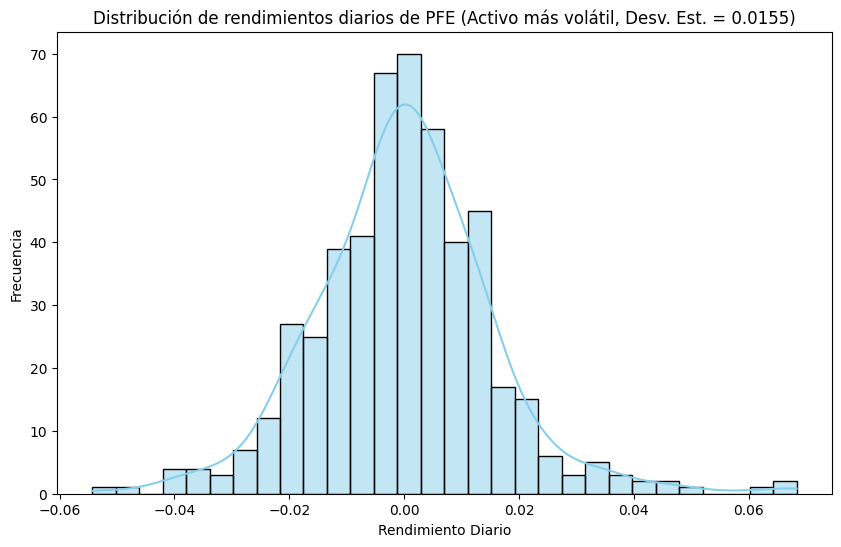

In [39]:
# 2. Histograma con el activo más volátil
import matplotlib.pyplot as plt
import seaborn as sns

# Identificamos el activo con mayor desviación estándar (más volátil)
activo_mas_volatil = rendimientos.std().idxmax()
std_volatil = rendimientos[activo_mas_volatil].std()

plt.figure(figsize=(10, 6))
sns.histplot(
    rendimientos[activo_mas_volatil].dropna(),
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title(f"Distribución de rendimientos diarios de {activo_mas_volatil} (Activo más volátil, Desv. Est. = {std_volatil:.4f})")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Frecuencia")

plt.show()

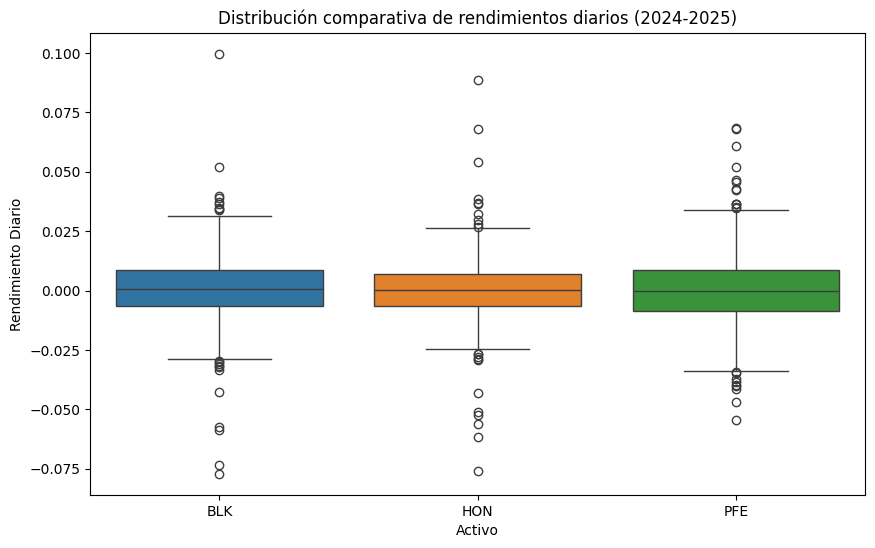

In [37]:
# 3. Boxplot comparativo de rendimientos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=rendimientos.dropna())

plt.title("Distribución comparativa de rendimientos diarios (2024-2025)")
plt.xlabel("Activo")
plt.ylabel("Rendimiento Diario")

plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

In [41]:
# 1. Calcular matriz de correlación
correlacion = rendimientos.corr()

correlacion



Ticker,BLK,HON,PFE
Ticker,,,
BLK,1.000000,0.494422,0.268618
HON,0.494422,1.000000,0.316589
PFE,0.268618,0.316589,1.000000


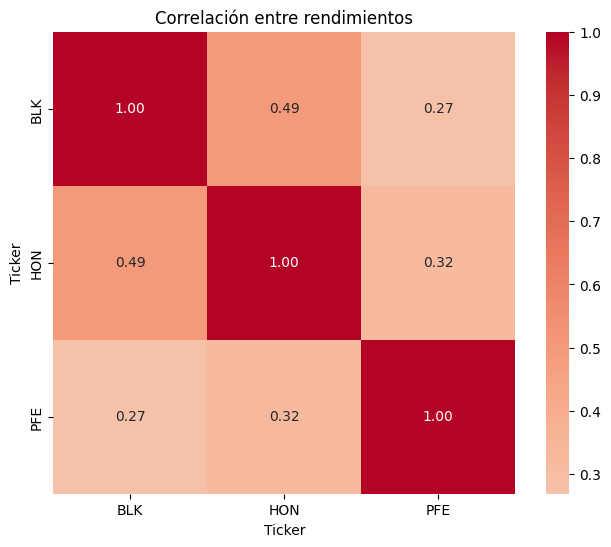

In [43]:
# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [46]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
import pandas as pd

resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
BLK,0.000775,0.000493,0.014659,-0.077133,0.099740
HON,0.000159,0.000088,0.013618,-0.075914,0.088811
PFE,0.000024,0.000000,0.015523,-0.054343,0.068344


In [47]:
print("=== RESUMEN DE PRECIOS DE CIERRE ===")
print(cierre.describe())
print("\n=== RESUMEN DE RENDIMIENTOS DIARIOS ===")
print(rendimientos.describe())

=== RESUMEN DE PRECIOS DE CIERRE ===
Ticker          BLK         HON         PFE
count    502.000000  502.000000  502.000000
mean     916.900150  201.408022   23.479290
std      129.680869   12.042739    1.342230
min      708.020447  175.464233   19.461584
25%      786.155487  191.330799   22.716299
50%      933.806274  201.614159   23.472575
75%     1018.971985  210.150555   24.294297
max     1177.427734  231.855682   27.409550

=== RESUMEN DE RENDIMIENTOS DIARIOS ===
Ticker         BLK         HON         PFE
count   501.000000  501.000000  501.000000
mean      0.000775    0.000159    0.000024
std       0.014659    0.013618    0.015523
min      -0.077133   -0.075914   -0.054343
25%      -0.006504   -0.006355   -0.008612
50%       0.000493    0.000088    0.000000
75%       0.008769    0.006824    0.008469
max       0.099740    0.088811    0.068344
